# Maps 

Author: Kat Le

Maps for faculty review and final presentations.

In [7]:
# Load packages 
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn
from matplotlib import colors
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.colors import LinearSegmentedColormap, BoundaryNorm

In [ ]:
pd.set_option('display.max_columns', None)

# Read in GeoJSON of all 
national_results = gpd.read_file('/capstone/justice40/github/j40-cejst-2/data/data-pipeline/data_pipeline/data/score/geojson/gi-star-values.geojson')
national_results.head()


In [ ]:
national_results.describe()

# Create contiguous map

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.cm as cm
from matplotlib.colorbar import ColorbarBase
from matplotlib_scalebar.scalebar import ScaleBar
import numpy as np
import seaborn as sns


contiguous_mask = (
    (national_results.geometry.centroid.x > -125) & 
    (national_results.geometry.centroid.x < -66) & 
    (national_results.geometry.centroid.y > 24) & 
    (national_results.geometry.centroid.y < 50)
)
contiguous_us = national_results[contiguous_mask].copy()

# Check your projection
if contiguous_us.crs is None or contiguous_us.crs.to_epsg() != 4326:
    # If not in WGS84 (EPSG:4326), reproject
    contiguous_us = contiguous_us.to_crs(epsg=4326)



/tmp/ipykernel_2143392/796044605.py:12: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.x > -125) &
/tmp/ipykernel_2143392/796044605.py:13: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.x < -66) &
/tmp/ipykernel_2143392/796044605.py:14: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  (national_results.geometry.centroid.y > 24) &
/tmp/ipykernel_2143392/796044605.py:15: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometr

# G* Burden Map

/opt/anaconda3/envs/justice40-env/lib/python3.10/site-packages/matplotlib_scalebar/scalebar.py:457: UserWarning: Drawing scalebar on axes with unequal aspect ratio; either call ax.set_aspect(1) or suppress the warning with rotation='horizontal-only'.
  warnings.warn(


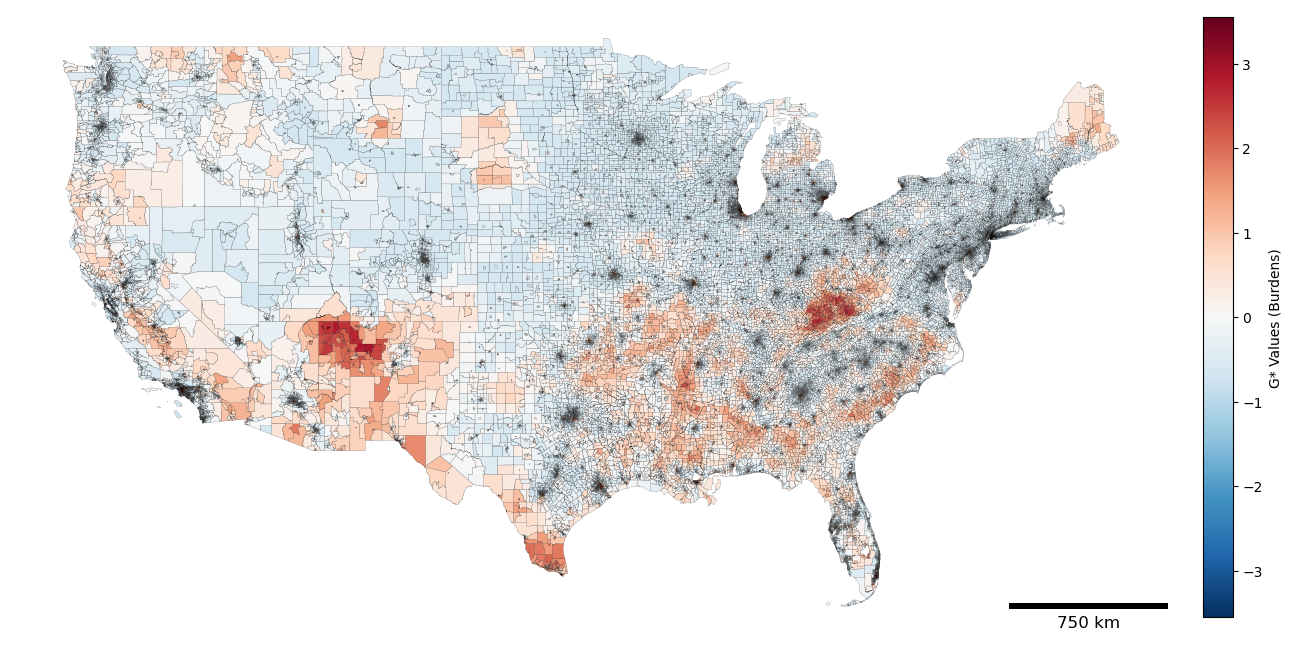

In [ ]:
# Create a figure with a specific size
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set up a diverging colormap (centered at 0 since standardized scores often have 0 as the mean)
# You can change the colormap to your preference
vmin = contiguous_us['gi_burd'].min()
vmax = contiguous_us['gi_burd'].max()
vabs = max(abs(vmin), abs(vmax))
norm = colors.Normalize(vmin=-vabs, vmax=vabs)
cmap = cm.RdBu_r  # Red-Blue diverging colormap, reversed

# Plot the data
contiguous_us.plot(
    column='gi_burd',
    cmap=cmap,
    norm=norm,
    linewidth=0.1,  # Thin black borders
    edgecolor='black',
    ax=ax
)

# Remove axes
ax.set_axis_off()

# Add scalebar for 4326 (degrees to meters at ~39°N)
scalebar_conus = ScaleBar(
    111000 * np.cos(np.radians(39)),  # meters per degree at CONUS latitude
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar_conus)

# Add a horizontal colorbar at the bottom
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
ColorbarBase(
    cbar_ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical', 
    label='G* Values (Burdens)'
)


# Save the figure
plt.savefig('../images/gstar_burd_map.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

# G* Indicators map 

In [ ]:
# Create a figure with a specific size
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set up a diverging colormap (centered at 0 since standardized scores often have 0 as the mean)
# You can change the colormap to your preference
vmin = contiguous_us['gi_ind'].min()
vmax = contiguous_us['gi_ind'].max()
vabs = max(abs(vmin), abs(vmax))
norm = colors.Normalize(vmin=-vabs, vmax=vabs)
cmap = cm.RdBu_r  # Red-Blue diverging colormap, reversed

# Plot the data
contiguous_us.plot(
    column='gi_ind',
    cmap=cmap,
    norm=norm,
    linewidth=0.1,  # Thin black borders
    edgecolor='black',
    ax=ax
)

# Remove axes
ax.set_axis_off()

# Add scalebar for 4326 (degrees to meters at ~39°N)
scalebar_conus = ScaleBar(
    111000 * np.cos(np.radians(39)),  # meters per degree at CONUS latitude
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar_conus)

# Add a horizontal colorbar at the bottom
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])  # [left, bottom, width, height]
ColorbarBase(
    cbar_ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical', 
    label='G* Values (Indicators)'
)


# Save the figure
plt.savefig('../images/gstar_ind_map.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

# Total Burdens map 1 (blue-red)

In [ ]:
# Create a figure with a specific size
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set up colormap with 0=blue, 8=red
vmin = contiguous_us['tot_burden'].min()
vmax = contiguous_us['tot_burden'].max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.RdBu_r  # Red-Blue diverging colormap, reversed

# Plot the data
contiguous_us.plot(
    column='tot_burden',
    cmap=cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor='black',
    ax=ax
)

# Remove axes
ax.set_axis_off()

# Add scalebar for 4326 (degrees to meters at ~39°N)
scalebar_conus = ScaleBar(
    111000 * np.cos(np.radians(39)),  # meters per degree at CONUS latitude
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar_conus)

# Add a vertical colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
ColorbarBase(
    cbar_ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical', 
    label='Total Burdens'
)

# Save the figure
plt.savefig('../images/tot_burd_map1.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

# Total burdens map 2 (Reds)

In [ ]:
# Create a figure with a specific size
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set up colormap with 0=blue, 8=red
vmin = contiguous_us['tot_burden'].min()
vmax = contiguous_us['tot_burden'].max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.Reds  

# Plot the data
contiguous_us.plot(
    column='tot_burden',
    cmap=cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor='black',
    ax=ax
)

# Remove axes
ax.set_axis_off()

# Add scalebar for 4326 (degrees to meters at ~39°N)
scalebar_conus = ScaleBar(
    111000 * np.cos(np.radians(39)),  # meters per degree at CONUS latitude
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar_conus)

# Add a vertical colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
ColorbarBase(
    cbar_ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical', 
    label='Total Burdens'
)

# Save the figure
plt.savefig('../images/tot_burd_map2.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

# Total burdens map 3 (rocket_r)

In [ ]:
# Create a figure with a specific size
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set up colormap with 0=blue, 8=red
vmin = contiguous_us['tot_burden'].min()
vmax = contiguous_us['tot_burden'].max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.get_cmap('rocket_r')  

# Plot the data
contiguous_us.plot(
    column='tot_burden',
    cmap=cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor='black',
    ax=ax
)

# Remove axes
ax.set_axis_off()

# Add scalebar for 4326 (degrees to meters at ~39°N)
scalebar_conus = ScaleBar(
    111000 * np.cos(np.radians(39)),  # meters per degree at CONUS latitude
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar_conus)

# Add a vertical colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
ColorbarBase(
    cbar_ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical', 
    label='Total Burdens'
)

# Save the figure
plt.savefig('../images/tot_burd_map3.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

# Total indicators map 1

In [ ]:
# Create a figure with a specific size
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set up colormap with 0=blue, 8=red
vmin = contiguous_us['tot_indica'].min()
vmax = contiguous_us['tot_indica'].max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.RdBu_r  # Red-Blue diverging colormap, reversed

# Plot the data
contiguous_us.plot(
    column='tot_indica',
    cmap=cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor='black',
    ax=ax
)

# Remove axes
ax.set_axis_off()

# Add scalebar for 4326 (degrees to meters at ~39°N)
scalebar_conus = ScaleBar(
    111000 * np.cos(np.radians(39)),  # meters per degree at CONUS latitude
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar_conus)

# Add a vertical colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
ColorbarBase(
    cbar_ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical', 
    label='Total Indicators'
)

# Save the figure
plt.savefig('../images/tot_indicators_map1.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

# Total indicators map 2

In [ ]:
# Create a figure with a specific size
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set up colormap with white to red
vmin = contiguous_us['tot_indica'].min()
vmax = contiguous_us['tot_indica'].max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = cm.Reds  # White to red colormap

# Plot the data
contiguous_us.plot(
    column='tot_indica',
    cmap=cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor='black',
    ax=ax
)

# Remove axes
ax.set_axis_off()

# Add scalebar for 4326 (degrees to meters at ~39°N)
scalebar_conus = ScaleBar(
    111000 * np.cos(np.radians(39)),  # meters per degree at CONUS latitude
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar_conus)

# Add a vertical colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
ColorbarBase(
    cbar_ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical', 
    label='Total Indicators'
)

# Save the figure
plt.savefig('../images/tot_indicators_map2.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()

# Total indiactors map 3 (rocket_r)

In [ ]:
# Create a figure with a specific size
fig, ax = plt.subplots(1, 1, figsize=(15, 10))

# Set up colormap with 0=blue, 8=red
vmin = contiguous_us['tot_indica'].min()
vmax = contiguous_us['tot_indica'].max()
norm = colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.get_cmap('rocket_r')  

# Plot the data
contiguous_us.plot(
    column='tot_indica',
    cmap=cmap,
    norm=norm,
    linewidth=0.1,
    edgecolor='black',
    ax=ax
)

# Remove axes
ax.set_axis_off()

# Add scalebar for 4326 (degrees to meters at ~39°N)
scalebar_conus = ScaleBar(
    111000 * np.cos(np.radians(39)),  # meters per degree at CONUS latitude
    dimension='si-length', 
    units='m', 
    location='lower right', 
    box_alpha=0.5,
    length_fraction=0.15,
    font_properties={'size': 12}
)
ax.add_artist(scalebar_conus)

# Add a vertical colorbar on the right
cbar_ax = fig.add_axes([0.92, 0.2, 0.02, 0.6])
ColorbarBase(
    cbar_ax, 
    cmap=cmap,
    norm=norm,
    orientation='vertical', 
    label='Total Indicators'
)

# Save the figure
plt.savefig('../images/tot_indicators_map3.png', dpi=300, bbox_inches='tight', transparent=True)

# Show the plot
plt.show()